# Preprocess

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

In [2]:
years = list(range(2000, 2025))
pdrb_values = [
    18595.52, 19716.73, 20891.32, 22144.12, 23472.25,
    24889.36, 26394.78, 27999.06, 29700.64, 31523.49,
    33501.20, 35880.50, 38375.10, 40908.50, 43465.20,
    46080.40, 48732.10, 51462.50, 54468.20, 57492.40,
    55435.50, 57698.20, 60254.80, 63285.15, 66520.40
]

# Buat DataFrame
df = pd.DataFrame({
    'Tahun': years,
    'PDRB': pdrb_values
})
df.set_index('Tahun', inplace=True)

print("Data PDRB ADHB BWI (2000-2024) - Data Terbaru:")
print(df.round(2))
print(f"\nTotal {len(df)} tahun")


Data PDRB ADHB BWI (2000-2024) - Data Terbaru:
           PDRB
Tahun          
2000   18595.52
2001   19716.73
2002   20891.32
2003   22144.12
2004   23472.25
2005   24889.36
2006   26394.78
2007   27999.06
2008   29700.64
2009   31523.49
2010   33501.20
2011   35880.50
2012   38375.10
2013   40908.50
2014   43465.20
2015   46080.40
2016   48732.10
2017   51462.50
2018   54468.20
2019   57492.40
2020   55435.50
2021   57698.20
2022   60254.80
2023   63285.15
2024   66520.40

Total 25 tahun


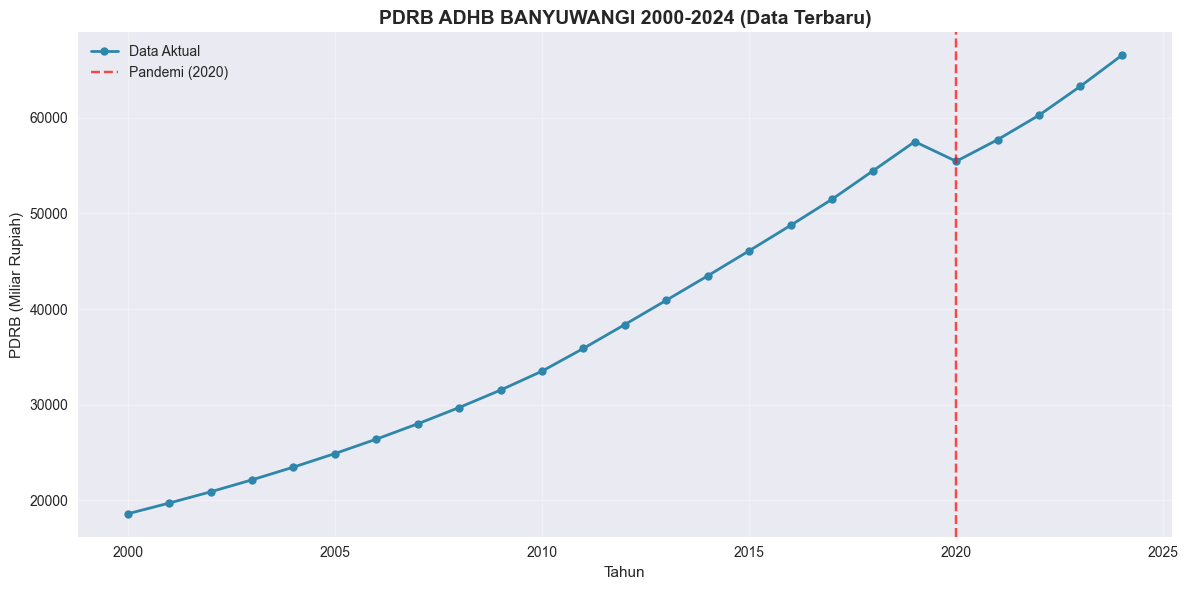

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['PDRB'], marker='o', linewidth=2, markersize=6, 
         color='#2E86AB', label='Data Aktual')
plt.axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='Pandemi (2020)')
plt.title('PDRB ADHB BANYUWANGI 2000-2024 (Data Terbaru)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('PDRB (Miliar Rupiah)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
result = adfuller(df['PDRB'])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('Data memiliki tren (non-stasioner)' if result[1] > 0.05 else 'Data stasioner')

ADF Statistic: 11.5167
p-value: 1.0000
Data memiliki tren (non-stasioner)


In [5]:
def calculate_mape(actual, forecast):
    """Hitung MAPE dengan handling nilai actual = 0"""
    actual, forecast = np.array(actual), np.array(forecast)
    mask = actual != 0
    if np.sum(mask) == 0:
        return np.nan
    mape = np.mean(np.abs((actual[mask] - forecast[mask]) / actual[mask])) * 100
    return mape

# HES

In [6]:
# Fit model Holt (tren aditif)
model = Holt(df['PDRB'], exponential=False, damped_trend=False)
fitted_model = model.fit(optimized=True)

# Tampilkan parameter optimal
print("\nParameter Optimal Model Holt:")
print(f"Smoothing Level (α): {fitted_model.params['smoothing_level']:.4f}")
print(f"Smoothing Trend (β) : {fitted_model.params['smoothing_trend']:.4f}")

# Hitung MAPE in-sample
mape_insample = calculate_mape(df['PDRB'], fitted_model.fittedvalues)
print(f"\nMAPE (In-Sample 2000-2024): {mape_insample:.2f}%")
print("Interpretasi:")
if mape_insample < 10:
    print("  → Sangat akurat (<10%)")
elif mape_insample < 20:
    print("  → Baik (10-20%)")
elif mape_insample < 30:
    print("  → Layak (20-30%)")
else:
    print("  → Perlu perbaikan (>30%)")


Parameter Optimal Model Holt:
Smoothing Level (α): 1.0000
Smoothing Trend (β) : 0.1946

MAPE (In-Sample 2000-2024): 1.80%
Interpretasi:
  → Sangat akurat (<10%)


In [7]:
# Forecast 5 tahun
forecast_years = 5
forecast = fitted_model.forecast(forecast_years)

# Buat DataFrame forecast
forecast_index = list(range(2025, 2025 + forecast_years))
df_forecast = pd.DataFrame({
    'Tahun': forecast_index,
    'PDRB_Forecast': forecast.values
})
df_forecast.set_index('Tahun', inplace=True)

print("\nHasil Forecast PDRB 2025-2029:")
print(df_forecast.round(2))

# Hitung pertumbuhan tahunan dari 2025-2029
pdrb_2024 = df.loc[2024, 'PDRB']  
growth_2025 = ((df_forecast.iloc[0]['PDRB_Forecast'] - pdrb_2024) / pdrb_2024) * 100

# Pertumbuhan tahun-tahun berikutnya (2026-2029)
forecast_growth = df_forecast['PDRB_Forecast'].pct_change() * 100

print("\nPertumbuhan Tahunan Forecast 2025-2029:")
# Print pertumbuhan 2025
print(f"  {forecast_index[0]}: {growth_2025:.2f}%")

# Print pertumbuhan 2026-2029
for tahun, growth in zip(forecast_index[1:], forecast_growth[1:]):
    print(f"  {tahun}: {growth:.2f}%")

# Hitung rata-rata pertumbuhan 2025-2029
all_growth = [growth_2025] + list(forecast_growth[1:].values)
print(f"Rata-rata pertumbuhan 2025-2029: {np.mean(all_growth):.2f}%")


Hasil Forecast PDRB 2025-2029:
       PDRB_Forecast
Tahun               
2025        68891.30
2026        71262.20
2027        73633.10
2028        76004.00
2029        78374.89

Pertumbuhan Tahunan Forecast 2025-2029:
  2025: 3.56%
  2026: 3.44%
  2027: 3.33%
  2028: 3.22%
  2029: 3.12%
Rata-rata pertumbuhan 2025-2029: 3.33%


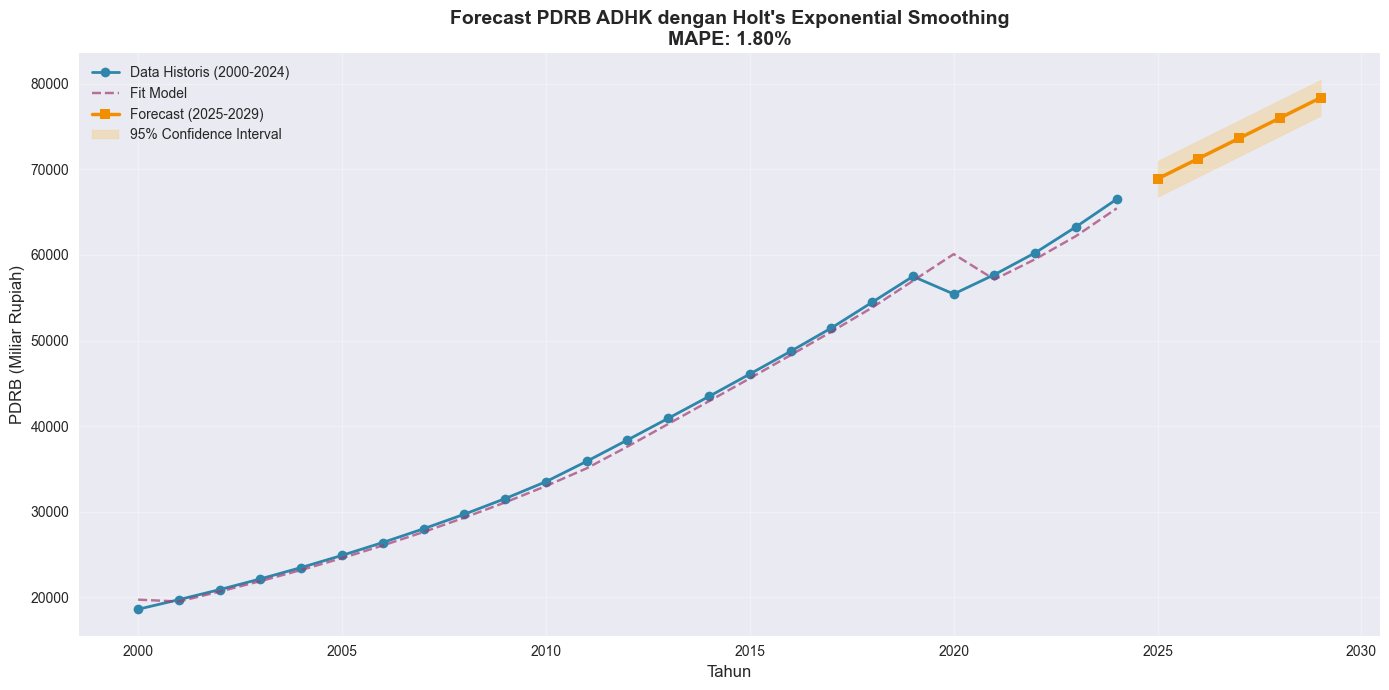

In [8]:
# Estimasi confidence interval berdasarkan error historis
residuals = df['PDRB'] - fitted_model.fittedvalues
std_error = np.std(residuals)

plt.figure(figsize=(14, 7))

# Data historis
plt.plot(df.index, df['PDRB'], marker='o', label='Data Historis (2000-2024)', 
         linewidth=2, color='#2E86AB')

# Fit model
plt.plot(df.index, fitted_model.fittedvalues, linestyle='--', 
         label='Fit Model', color='#A23B72', alpha=0.7)

# Forecast
plt.plot(df_forecast.index, df_forecast['PDRB_Forecast'], marker='s', 
         label='Forecast (2025-2029)', linewidth=2.5, color='#F18F01')

# Confidence interval (±1.96 * std error)
plt.fill_between(
    df_forecast.index,
    df_forecast['PDRB_Forecast'] - 1.96 * std_error,
    df_forecast['PDRB_Forecast'] + 1.96 * std_error,
    color='orange', alpha=0.2, label='95% Confidence Interval'
)

plt.title(f'Forecast PDRB ADHK dengan Holt\'s Exponential Smoothing\n'
          f'MAPE: {mape_insample:.2f}%', 
          fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('PDRB (Miliar Rupiah)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Log ARIMA

In [2]:
years = list(range(2000, 2025))
pdrb_values = [
    18595.52, 19716.73, 20891.32, 22144.12, 23472.25,
    24889.36, 26394.78, 27999.06, 29700.64, 31523.49,
    33501.20, 35880.50, 38375.10, 40908.50, 43465.20,
    46080.40, 48732.10, 51462.50, 54468.20, 57492.40,
    55435.50, 57698.20, 60254.80, 63285.15, 66520.40
]

df = pd.DataFrame({
    'Tahun': years,
    'PDRB': pdrb_values
})
df['Tanggal'] = pd.to_datetime(df['Tahun'].astype(str) + '-12-31')
df = df.set_index('Tanggal')

print("Data PDRB ADHK (2000-2024) - Data Terbaru:")
print(df[['Tahun', 'PDRB']].round(2))
print(f"\nTotal data: {len(df)} tahun")

# 2. HITUNG PERSENTASE KENAIKAN TAHUNAN
df['Pertumbuhan (%)'] = df['PDRB'].pct_change() * 100

# Format kolom pertumbuhan dengan highlight negatif/positif
def format_growth(val):
    if pd.isna(val):
        return "-"
    elif val < 0:
        return f"▼ {val:.2f}%"
    else:
        return f"▲ {val:.2f}%"

print("Data PDRB ADHK (2000-2024) dengan Pertumbuhan Tahunan:")
print("="*70)
print(f"{'Tahun':<8} {'PDRB (Miliar Rp)':<25} {'Pertumbuhan (%)':<20}")
print("="*70)

for idx, row in df.iterrows():
    tahun = row['Tahun']
    pdrb = f"Rp {row['PDRB']:,.2f}"
    growth = format_growth(row['Pertumbuhan (%)'])
    print(f"{tahun:<8} {pdrb:<25} {growth:<20}")

print("="*70)

Data PDRB ADHK (2000-2024) - Data Terbaru:
            Tahun      PDRB
Tanggal                    
2000-12-31   2000  18595.52
2001-12-31   2001  19716.73
2002-12-31   2002  20891.32
2003-12-31   2003  22144.12
2004-12-31   2004  23472.25
2005-12-31   2005  24889.36
2006-12-31   2006  26394.78
2007-12-31   2007  27999.06
2008-12-31   2008  29700.64
2009-12-31   2009  31523.49
2010-12-31   2010  33501.20
2011-12-31   2011  35880.50
2012-12-31   2012  38375.10
2013-12-31   2013  40908.50
2014-12-31   2014  43465.20
2015-12-31   2015  46080.40
2016-12-31   2016  48732.10
2017-12-31   2017  51462.50
2018-12-31   2018  54468.20
2019-12-31   2019  57492.40
2020-12-31   2020  55435.50
2021-12-31   2021  57698.20
2022-12-31   2022  60254.80
2023-12-31   2023  63285.15
2024-12-31   2024  66520.40

Total data: 25 tahun
Data PDRB ADHK (2000-2024) dengan Pertumbuhan Tahunan:
Tahun    PDRB (Miliar Rp)          Pertumbuhan (%)     
2000.0   Rp 18,595.52              -                   
2001.0   Rp 

## Uji Stationer

In [3]:
print("\n" + "="*60)
print("UJI STASIONERITAS (ADF TEST)")
print("="*60)
result = adfuller(df['PDRB'])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('Kesimpulan: Data STASIONER' if result[1] < 0.05 else 'Kesimpulan: Data NON-STASIONER (perlu differencing)')



UJI STASIONERITAS (ADF TEST)
ADF Statistic: 11.5167
p-value: 1.0000
Kesimpulan: Data NON-STASIONER (perlu differencing)


### Diff 1

In [4]:
# 3. DIFFERENCING PERTAMA (d=1)
print("\n" + "="*60)
print("DIFFERENCING PERTAMA (d=1): Δy_t = y_t - y_{t-1}")
print("="*60)
df['PDRB_diff1'] = df['PDRB'].diff()

# Tampilkan contoh perhitungan differencing
print("\nContoh Perhitungan Differencing:")
print(f"  Δy_2001 = y_2001 - y_2000 = {df.loc['2001-12-31', 'PDRB']:.2f} - {df.loc['2000-12-31', 'PDRB']:.2f} = {df.loc['2001-12-31', 'PDRB_diff1']:.2f}")
print(f"  Δy_2020 = y_2020 - y_2019 = {df.loc['2020-12-31', 'PDRB']:.2f} - {df.loc['2019-12-31', 'PDRB']:.2f} = {df.loc['2020-12-31', 'PDRB_diff1']:.2f} (kontraksi pandemi)")

# 4. UJI STASIONERITAS SETELAH DIFFERENCING PERTAMA
result_diff1 = adfuller(df['PDRB_diff1'].dropna())
print("\n" + "="*60)
print("UJI STASIONERITAS - SETELAH DIFFERENCING PERTAMA")
print("="*60)
print(f"ADF Statistic: {result_diff1[0]:.4f}")
print(f"p-value      : {result_diff1[1]:.4f}")
print(f"Kesimpulan   : {'STASIONER' if result_diff1[1] < 0.05 else 'MASIH NON-STASIONER (perlu differencing kedua)'}")



DIFFERENCING PERTAMA (d=1): Δy_t = y_t - y_{t-1}

Contoh Perhitungan Differencing:
  Δy_2001 = y_2001 - y_2000 = 19716.73 - 18595.52 = 1121.21
  Δy_2020 = y_2020 - y_2019 = 55435.50 - 57492.40 = -2056.90 (kontraksi pandemi)

UJI STASIONERITAS - SETELAH DIFFERENCING PERTAMA
ADF Statistic: 0.2000
p-value      : 0.9723
Kesimpulan   : MASIH NON-STASIONER (perlu differencing kedua)


### Diff 2

In [5]:
# 5. DIFFERENCING KEDUA (d=2) - Jika diperlukan
if result_diff1[1] >= 0.05:
    print("\n" + "="*60)
    print("DIFFERENCING KEDUA (d=2): Δ²y_t = Δy_t - Δy_{t-1}")
    print("="*60)
    df['PDRB_diff2'] = df['PDRB_diff1'].diff()
    
    result_diff2 = adfuller(df['PDRB_diff2'].dropna())
    print(f"\nADF Statistic: {result_diff2[0]:.4f}")
    print(f"p-value      : {result_diff2[1]:.4f}")
    print(f"Kesimpulan   : {'STASIONER' if result_diff2[1] < 0.05 else 'MASIH NON-STASIONER'}")



DIFFERENCING KEDUA (d=2): Δ²y_t = Δy_t - Δy_{t-1}

ADF Statistic: -8.4406
p-value      : 0.0000
Kesimpulan   : STASIONER


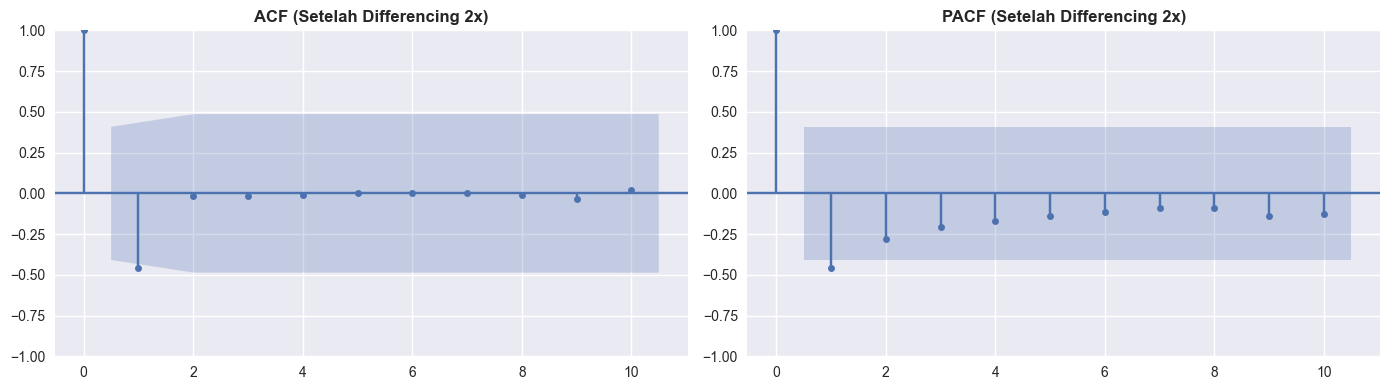

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['PDRB_diff2'].dropna(), ax=axes[0], lags=10)
plot_pacf(df['PDRB_diff2'].dropna(), ax=axes[1], lags=10)
axes[0].set_title('ACF (Setelah Differencing 2x)', fontsize=12, fontweight='bold')
axes[1].set_title('PACF (Setelah Differencing 2x)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Splitting

In [7]:
train = df.loc[:'2020-12-31']
test = df.loc['2021-12-31':]

print("\n" + "="*60)
print("SPLIT DATA (VALIDASI DIPERLUAS)")
print("="*60)
print(f"Data Train: {train.index.min().year} - {train.index.max().year} ({len(train)} tahun)")
print(f"Data Test : {test.index.min().year} - {test.index.max().year} ({len(test)} tahun)")
print("Catatan: Test set mencakup periode pandemi (2021) dan pemulihan (2022-2024)")


SPLIT DATA (VALIDASI DIPERLUAS)
Data Train: 2000 - 2020 (21 tahun)
Data Test : 2021 - 2024 (4 tahun)
Catatan: Test set mencakup periode pandemi (2021) dan pemulihan (2022-2024)


## Log Transformasi

In [8]:
# 4. LOG-TRANSFORMASI (Pra-pemrosesan untuk Log-ARIMA)
print("\n" + "="*70)
print("LOG-TRANSFORMASI DATA")
print("="*70)
train_log = np.log(train['PDRB'])
test_log = np.log(test['PDRB'])


LOG-TRANSFORMASI DATA


## Fit Model

In [9]:
from statsmodels.tsa.arima.model import ARIMA

#FIT MODEL LOG-ARIMA(0,1,1) + DRIFT
print("="*70)
print("FIT MODEL LOG-ARIMA(0,1,1) + DRIFT")
print("="*70)

model_log = ARIMA(train_log, order=(0, 1, 1), trend='t')
fitted_log = model_log.fit()



FIT MODEL LOG-ARIMA(0,1,1) + DRIFT


In [10]:
#Tampilkan parameter model
print(f"\nParameter Model (Skala Log):")
drift_param = fitted_log.params.get('const', np.nan)
print(f"  Drift (c)       : {drift_param:.6f}")
print(f"  MA(1) Coef (θ)  : {fitted_log.params['ma.L1']:.6f}")
print(f"  Variance (σ²)   : {fitted_log.params['sigma2']:.6f}")
print(f"\nInterpretasi Drift:")
print(f"  c = {drift_param:.6f} → Pertumbuhan rata-rata {(np.exp(drift_param) - 1)*100:.2f}%/tahun")

# 7. VALIDASI PADA DATA TEST (2021-2024)
print("\n" + "="*70)
print("VALIDASI MODEL PADA DATA TEST (2021-2024)")
print("="*70)


Parameter Model (Skala Log):
  Drift (c)       : nan
  MA(1) Coef (θ)  : 0.630748
  Variance (σ²)   : 0.000415

Interpretasi Drift:
  c = nan → Pertumbuhan rata-rata nan%/tahun

VALIDASI MODEL PADA DATA TEST (2021-2024)


## Forecast Log

In [11]:
# Forecast pada skala log
forecast_log = fitted_log.forecast(steps=len(test))

# Back-transform ke skala asli (tanpa koreksi bias untuk simplicity)
forecast_original = np.exp(forecast_log)

## MAPE Testing

In [12]:
# Hitung MAPE
def calculate_mape(actual, forecast):
    return np.mean(np.abs((actual - forecast) / actual)) * 100

mape_test = calculate_mape(test['PDRB'], forecast_original)
print(f"MAPE pada Data Test (2021-2024): {mape_test:.3f}%")

MAPE pada Data Test (2021-2024): 3.460%


In [13]:
# Tampilkan perbandingan detail
comparison = pd.DataFrame({
    'Tahun': test['Tahun'].values,
    'Aktual': test['PDRB'].values,
    'Forecast': forecast_original.values,
    'Error (%)': np.abs((test['PDRB'].values - forecast_original.values) / test['PDRB'].values) * 100
})
print("\nPerbandingan Detail Aktual vs Forecast:")
print(comparison.round(2).to_string(index=False))

#Analisis error per tahun
print("\nAnalisis Error:")
for idx, row in comparison.iterrows():
    status = "✓" if row['Error (%)'] < 2 else "⚠"
    print(f"  {status} {int(row['Tahun'])}: Error {row['Error (%)']:.2f}%")



Perbandingan Detail Aktual vs Forecast:
 Tahun   Aktual  Forecast  Error (%)
  2021 57698.20  55232.77       4.27
  2022 60254.80  58179.29       3.44
  2023 63285.15  61283.00       3.16
  2024 66520.40  64552.28       2.96

Analisis Error:
  ⚠ 2021: Error 4.27%
  ⚠ 2022: Error 3.44%
  ⚠ 2023: Error 3.16%
  ⚠ 2024: Error 2.96%


## Fit Model Final

In [14]:
# 8. FIT MODEL FINAL PADA SELURUH DATA (2000-2024)
print("\n" + "="*70)
print("MODEL FINAL: FIT PADA SELURUH DATA (2000-2024)")
print("="*70)

full_log = np.log(df['PDRB'])
model_full = ARIMA(full_log, order=(0, 1, 1), trend='t')
fitted_full = model_full.fit()

print(f"Parameter Final:")
drift_param = fitted_full.params.get('const', np.nan)
print(f"  Drift (c)       : {drift_param:.6f} → {(np.exp(drift_param) - 1)*100:.2f}%/tahun")
print(f"  MA(1) Coef (θ)  : {fitted_full.params['ma.L1']:.6f}")
print(f"  AIC             : {fitted_full.aic:.2f}")
print(f"  BIC             : {fitted_full.bic:.2f}")



MODEL FINAL: FIT PADA SELURUH DATA (2000-2024)
Parameter Final:
  Drift (c)       : nan → nan%/tahun
  MA(1) Coef (θ)  : 0.188358
  AIC             : -115.47
  BIC             : -111.94


In [15]:
# 9. FORECAST 4 TAHUN KE DEPAN (2025-2028)
print("\n" + "="*70)
print("FORECAST 4 TAHUN KE DEPAN (2025-2028)")
print("="*70)

forecast_steps = 4
forecast_log_full = fitted_full.get_forecast(steps=forecast_steps)
forecast_mean_log = forecast_log_full.predicted_mean
forecast_ci_log = forecast_log_full.conf_int(alpha=0.05)
forecast_mean = np.exp(forecast_mean_log)
forecast_ci_lower = np.exp(forecast_ci_log.iloc[:, 0])
forecast_ci_upper = np.exp(forecast_ci_log.iloc[:, 1])

forecast_years = [2025, 2026, 2027, 2028]
df_forecast = pd.DataFrame({
    'Tahun': forecast_years,
    'PDRB_Forecast': forecast_mean.values,
    'Lower_95%': forecast_ci_lower.values,
    'Upper_95%': forecast_ci_upper.values
})



FORECAST 4 TAHUN KE DEPAN (2025-2028)


## Hasil Forecast

In [16]:
print(df_forecast.round(2).to_string(index=False))

 Tahun  PDRB_Forecast  Lower_95%  Upper_95%
  2025       70111.44   67516.44   72806.19
  2026       73936.29   69729.79   78396.54
  2027       77969.79   72426.03   83937.88
  2028       82223.33   75424.61   89634.88


In [17]:
print("\n" + "="*70)
print("PERTUMBUHAN TAHUNAN FORECAST (2025-2028)")
print("="*70)

# Pertumbuhan 2025 (dari 2024 historis ke 2025 forecast)
growth_2025 = ((df_forecast.loc[0, 'PDRB_Forecast'] - df.loc['2024-12-31', 'PDRB']) / df.loc['2024-12-31', 'PDRB']) * 100
print(f"  2025: +{growth_2025:.2f}% (dari 2024 → 2025)")

# Pertumbuhan 2026-2028
forecast_growth = []
for i in range(1, len(df_forecast)):
    growth = ((df_forecast.loc[i, 'PDRB_Forecast'] - df_forecast.loc[i-1, 'PDRB_Forecast']) / df_forecast.loc[i-1, 'PDRB_Forecast']) * 100
    forecast_growth.append(growth)
    print(f"  {forecast_years[i]}: +{growth:.2f}% (dari {forecast_years[i-1]} → {forecast_years[i]})")



PERTUMBUHAN TAHUNAN FORECAST (2025-2028)
  2025: +5.40% (dari 2024 → 2025)
  2026: +5.46% (dari 2025 → 2026)
  2027: +5.46% (dari 2026 → 2027)
  2028: +5.46% (dari 2027 → 2028)


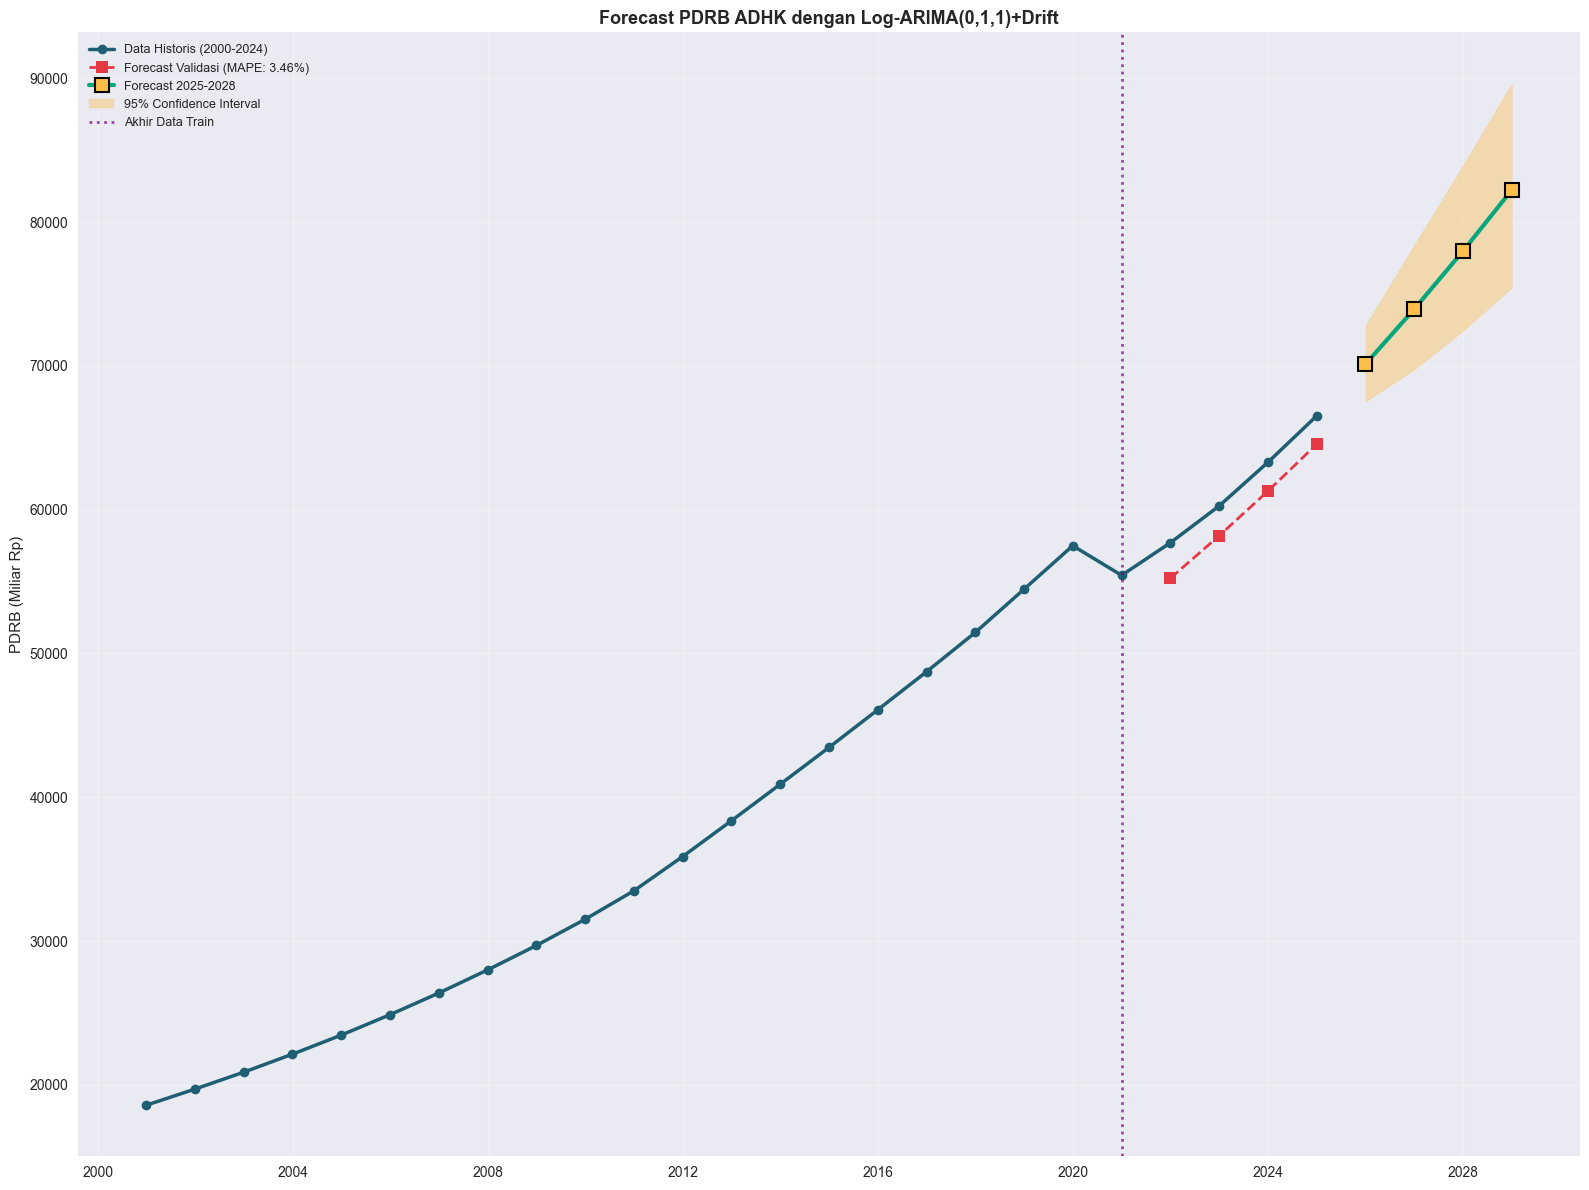

In [18]:
fig, axes = plt.subplots(1, 1, figsize=(16, 12))
# Plot 1: Data Historis + Forecast
axes.plot(df.index, df['PDRB'], 'o-', label='Data Historis (2000-2024)', 
          linewidth=2.5, markersize=7, color='#1E5F74')
axes.plot(test.index, forecast_original, 's--', label=f'Forecast Validasi (MAPE: {mape_test:.2f}%)', 
          linewidth=2, markersize=8, color='#E63946')
axes.plot(pd.date_range('2025-12-31', periods=4, freq='YE'), 
          forecast_mean, 's-', label='Forecast 2025-2028', 
          linewidth=3, markersize=10, color='#06A77D', 
          markerfacecolor='#FCBF49', markeredgecolor='black', markeredgewidth=1.5)
axes.fill_between(pd.date_range('2025-12-31', periods=4, freq='YE'),
                  forecast_ci_lower, forecast_ci_upper, 
                  color='#FCBF49', alpha=0.4, label='95% Confidence Interval')
axes.axvline(x=pd.Timestamp('2020-12-31'), color='purple', linestyle=':', 
             linewidth=2, alpha=0.7, label='Akhir Data Train')
axes.set_title('Forecast PDRB ADHK dengan Log-ARIMA(0,1,1)+Drift', 
               fontsize=13, fontweight='bold')
axes.set_ylabel('PDRB (Miliar Rp)', fontsize=11)
axes.legend(fontsize=9, loc='upper left')
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
